# JobLib: A First Parallel Program

> Derived from Chapter 1 of Mattson, *Parallel Computing for Data Science*.

## Mutual Outlinks

Big data analytics and graph processing grew out of the desire to understand the structure of Internet content and user behavior. The most famous example is the [PageRank algorithm](https://en.wikipedia.org/wiki/PageRank), which changed the nature of Internet search and was crucial in the early success of Google.

We look at a simpler but representative problem: **identifying Web pages that link to the same content**. Multiple pages with the same outlinks may indicate:
- **Content clusters** — topically similar pages
- **Search engine gamification** — pages artificially boosting a target's rank

Here is AI's list of examples that include applications beyond the Web. It applies on any graph.


### Web & Search

* Link farm detection — pages with identical outlink sets are likely manufactured to game PageRank
* Topic clustering — pages linking to the same authoritative sources tend to be topically related (basis of HITS / hub-authority analysis)

### Social Networks

* Friend recommendation — "people you may know" is often just mutual outlinks on a follower graph
* Community detection — nodes with high mutual outlinks cluster into the same community more reliably than raw edge counts

### Citation Networks

* Bibliographic coupling — two papers citing the same sources are likely in the same research area; this predates the web and is one of the original graph similarity metrics (Kessler, 1963)
* Research trend analysis — sudden increases in mutual outlinks signal an emerging subfield coalescing around shared foundational papers

### Recommendation Systems

* Collaborative filtering — users who clicked/purchased the same items have high mutual outlinks on a user→item bipartite graph; this is the core of item-based CF

### Bioinformatics

* Gene co-regulation — genes that share many transcription factor binding targets are likely co-regulated; mutual outlinks on a gene→target graph surfaces these pairs

### Security

* Botnet fingerprinting — C2 infrastructure nodes that contact the same set of victim IPs share outlinks; clustering by mutual outlinks groups bots to the same campaign

## Algorithm

The input is a **directed graph**: each Web page is a node, and edges represent outbound links.

### Goals for this notebook
1. Build the algorithm on a small graph and verify correctness by hand
2. Scale up and parallelize with `joblib` — observe the limits of Python parallelism
3. Rewrite using BLAS matrix operations — show what "the right tool" looks like

In [ ]:
import time
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

%matplotlib inline

def bench(fn, reps=3):
    """Return mean wall time over `reps` calls."""
    t0 = time.perf_counter()
    for _ in range(reps):
        fn()
    return (time.perf_counter() - t0) / reps

---
## Part 1: Small Graph — Verifying Correctness

Before worrying about performance, we need an implementation we trust. We use a small [Erdős–Rényi](https://en.wikipedia.org/wiki/Erd%C5%91s%E2%80%93R%C3%A9nyi_model) random directed graph with 5 nodes and edge probability 0.6 so we can inspect the result by hand.

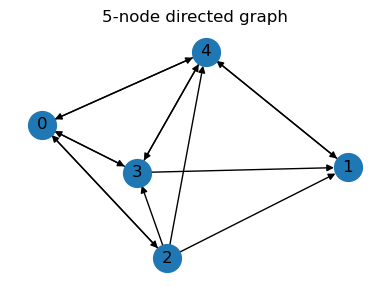

Adjacency matrix (row i has a 1 in column j if node i links to node j):
[[0 0 1 1 1]
 [0 0 0 0 1]
 [1 1 0 1 1]
 [1 1 0 0 1]
 [1 1 0 1 0]]


In [ ]:
np.random.seed(42)
G_small = nx.erdos_renyi_graph(5, 0.6, directed=True, seed=42)

fig, ax = plt.subplots(figsize=(4, 3))
pos = nx.spring_layout(G_small, seed=42)
nx.draw_networkx(G_small, pos=pos, ax=ax, node_size=400, arrows=True)
ax.set_title("5-node directed graph")
ax.axis("off")
plt.tight_layout()
plt.show()

gmat_small = nx.to_numpy_array(G_small)
print("Adjacency matrix (row i has a 1 in column j if node i links to node j):")
print(gmat_small.astype(int))

### The Mutual Outlinks Algorithm

For every pair of nodes $(i, j)$ with $i < j$, count the number of nodes they both link to:

$$\text{outmat}[i,j] = \sum_k \text{gmat}[i,k] \cdot \text{gmat}[j,k] = \vec{r}_i \cdot \vec{r}_j$$

This is a dot product of two rows of the adjacency matrix. We only compute the **upper triangle** ($i < j$) because the lower triangle would be symmetric and redundant.

In [ ]:
def serial_outlinks(gmat):
    n = gmat.shape[0]
    outmat = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            outmat[i, j] = np.dot(gmat[i, :], gmat[j, :])
    return outmat

outmat_small = serial_outlinks(gmat_small)

print("Adjacency matrix:")
print(gmat_small.astype(int))
print("\nMutual outlinks (upper triangle):")
print(outmat_small.astype(int))

Adjacency matrix:
[[0 0 1 1 1]
 [0 0 0 0 1]
 [1 1 0 1 1]
 [1 1 0 0 1]
 [1 1 0 1 0]]

Mutual outlinks (upper triangle):
[[0 1 2 1 1]
 [0 0 1 1 0]
 [0 0 0 3 3]
 [0 0 0 0 2]
 [0 0 0 0 0]]


### Verifying by Hand

Pick any entry and check it against the adjacency matrix. For example, `outmat[0,1]` should equal the number of columns where both row 0 and row 1 have a 1 — i.e., nodes that both node 0 and node 1 link to.

Count those shared outlinks manually and confirm the matrix entry is correct before moving on.

In [ ]:
i, j = 0, 1
shared = np.where((gmat_small[i, :] == 1) & (gmat_small[j, :] == 1))[0]
print(f"Row {i}: {gmat_small[i, :].astype(int)}")
print(f"Row {j}: {gmat_small[j, :].astype(int)}")
print(f"Nodes both {i} and {j} link to: {shared}")
print(f"outmat[{i},{j}] = {int(outmat_small[i, j])}  (expected {len(shared)})")

Row 0: [0 0 1 1 1]
Row 1: [0 0 0 0 1]
Nodes both 0 and 1 link to: [4]
outmat[0,1] = 1  (expected 1)


---
## Part 2: Scaling Up — Python Parallelism with `joblib`

A 5-node graph is trivial. Real web graphs have millions of nodes. Let's grow to **1,000 nodes** with roughly 5 outbound edges per node and see how the serial algorithm performs.

In [ ]:
G = nx.erdos_renyi_graph(1000, 0.01, directed=True, seed=0)
gmat = nx.to_numpy_array(G)
print(f"Nodes: {G.number_of_nodes()},  Edges: {G.number_of_edges()}")
print(f"Matrix size: {gmat.shape}")

# Establish serial baseline
outmat_serial = serial_outlinks(gmat)
serial_1k = bench(lambda: serial_outlinks(gmat))
print(f"\nNon-zero mutual outlinks: {np.count_nonzero(outmat_serial)}")
print(f"Serial time (1000 nodes): {serial_1k:.3f}s")

Nodes: 1000,  Edges: 10052
Matrix size: (1000, 1000)

Non-zero mutual outlinks: 47864
Serial time (1000 nodes): 0.237s


### Parallelizing with `joblib`

The outer loop over rows is **embarrassingly parallel**: each row's computation is independent. We extract it into a function and let `joblib` run the rows concurrently across worker processes.

```
Parallel(n_jobs=8)(
    delayed(inner_loop)(gmat, i)    ← build a list of deferred calls
    for i in range(n)               ← one call per row
)                                   ← execute them across 8 workers
```

- **`delayed`**: wraps a function call without executing it yet
- **`Parallel`**: dispatches the deferred calls across `n_jobs` worker processes and collects results

In [ ]:
def inner_loop(gmat, i):
    """Compute row i of the mutual outlinks matrix."""
    n = gmat.shape[1]
    partial = np.zeros(n)
    for j in range(i + 1, n):
        partial[j] = np.dot(gmat[i, :], gmat[j, :])
    return partial

# Correctness check
partials = Parallel(n_jobs=8)(delayed(inner_loop)(gmat, i) for i in range(gmat.shape[0]))
outmat_par = np.array(partials)

print(f"Serial   non-zero: {np.count_nonzero(outmat_serial)}")
print(f"Parallel non-zero: {np.count_nonzero(outmat_par)}")
print(f"Results match: {np.allclose(outmat_serial, outmat_par)}")

Serial   non-zero: 47864
Parallel non-zero: 47864
Results match: True


In [ ]:
parallel_1k = bench(
    lambda: Parallel(n_jobs=8)(delayed(inner_loop)(gmat, i) for i in range(gmat.shape[0]))
)
print(f"Serial   (1000 nodes): {serial_1k:.3f}s")
print(f"Parallel (1000 nodes): {parallel_1k:.3f}s")
print(f"Speedup: {serial_1k / parallel_1k:.2f}x  (8 workers)")

Serial   (1000 nodes): 0.237s
Parallel (1000 nodes): 0.297s
Speedup: 0.80x  (8 workers)


### The speedup is less than 1×?

At 1,000 nodes the graph is **too small**: shipping `gmat` (a 1000×1000 = 8 MB matrix) to 8 worker processes costs more than the compute saved. Let's scale up to **5,000 nodes** where the work-per-row actually justifies the overhead.

In [ ]:
G5k = nx.erdos_renyi_graph(5000, 0.01, directed=True, seed=0)
gmat5k = nx.to_numpy_array(G5k)
print(f"Nodes: {G5k.number_of_nodes()},  Edges: {G5k.number_of_edges()}")

serial_5k = bench(lambda: serial_outlinks(gmat5k), reps=1)
parallel_5k = bench(
    lambda: Parallel(n_jobs=8)(delayed(inner_loop)(gmat5k, i) for i in range(gmat5k.shape[0])),
    reps=1
)
print(f"\nSerial   (5000 nodes): {serial_5k:.2f}s")
print(f"Parallel (5000 nodes): {parallel_5k:.2f}s")
print(f"Speedup: {serial_5k / parallel_5k:.2f}x  (8 workers)")

Nodes: 5000,  Edges: 250297

Serial   (5000 nodes): 12.36s
Parallel (5000 nodes): 6.22s
Speedup: 1.99x  (8 workers)


### Threads vs Processes in joblib

joblib supports both backends via `prefer=`:
- **`"loky"` (default)** — worker *processes*, each with its own GIL; no shared memory, matrix must be pickled per call
- **`"threads"`** — worker *threads* in the same process; shared memory (no IPC cost), but all threads share one GIL

For this workload the comparison is instructive: `inner_loop` is a Python `for` loop that calls `np.dot` on each iteration. `np.dot` **releases the GIL** during the BLAS call, so threads *can* overlap during the matrix multiply — but the Python loop reacquires the GIL between every dot product. With 8 threads each running 5000-iteration loops simultaneously, they spend most of their time **fighting over the GIL** rather than computing. The result is not just "no speedup" — it is actively slower than serial.

In [ ]:
thread_5k = bench(
    lambda: Parallel(n_jobs=8, prefer="threads")(delayed(inner_loop)(gmat5k, i) for i in range(gmat5k.shape[0])),
    reps=1
)

print(f"{'Method':<35} {'Time':>8}  {'Speedup':>10}  {'Notes'}")
print("-" * 75)
print(f"{'Serial':<35} {serial_5k:>7.2f}s  {'1.00x':>10}  baseline")
print(f"{'Parallel (threads)':<35} {thread_5k:>7.2f}s  {serial_5k/thread_5k:>9.2f}x  shared memory, GIL fragments np.dot gains")
print(f"{'Parallel (processes, default)':<35} {parallel_5k:>7.2f}s  {serial_5k/parallel_5k:>9.2f}x  independent GILs, ~200MB pickle overhead")

### Reading the results

**Threads (~0.2× — slower than serial)**: No IPC cost, but 8 threads all contend for the same GIL on every Python loop iteration. The lock thrashing overwhelms any benefit from overlapping `np.dot` calls. Threads are not just unhelpful here — they make things significantly worse.

**Processes (~1.7× — modest gain)**: Each process has its own independent GIL, so there is no lock contention. True parallelism. But the 5000×5000 matrix (~200 MB) must be pickled and shipped to each of the 8 workers on every call, eating most of the potential speedup.

The two approaches expose the two fundamental constraints on Python parallelism:

| | Threads | Processes |
|---|---|---|
| GIL contention | Yes — all threads share one GIL | No — each process has its own |
| IPC / copy cost | None — shared memory | High — pickle per call |
| Practical speedup (this workload) | 0.2× ❌ | 1.7× ⚠️ |

Neither approach escapes both constraints at once. That is the setup for Part 3.

---
## Part 3: The Right Tool — Vectorized BLAS

The nested loop we've been parallelizing is just a matrix multiplication in disguise.

$$
\text{outmat}[i,j] = \vec{r}_i \cdot \vec{r}_j = (\mathbf{G}\, \mathbf{G}^T)[i,j]
$$

The full matrix product $\mathbf{G}\mathbf{G}^T$ computes every pairwise dot product simultaneously. We only want the upper triangle ($i < j$, since $i = j$ would be self-outlinks and the lower triangle is redundant), so we call `np.triu(..., k=1)`.

This hands the entire computation to **BLAS** (Basic Linear Algebra Subprograms), a library of hand-tuned, SIMD-vectorized, internally multi-threaded routines. BLAS was written in Fortran in the 1970s and has been optimized for every CPU microarchitecture since.

In [ ]:
def vectorized_outlinks(gmat):
    return np.triu(gmat @ gmat.T, k=1)

# Correctness: compare against serial result on small graph
outmat_vec_small = vectorized_outlinks(gmat_small)
print("Serial result (small graph):")
print(outmat_small.astype(int))
print("\nVectorized result (small graph):")
print(outmat_vec_small.astype(int))
print(f"\nResults match: {np.allclose(outmat_small, outmat_vec_small)}")

In [ ]:
# Full comparison at 5000 nodes
vec_5k = bench(lambda: vectorized_outlinks(gmat5k), reps=3)

print(f"{'Method':<30} {'Time':>8}  {'Speedup':>10}")
print("-" * 52)
print(f"{'Serial (Python loops)':<30} {serial_5k:>7.2f}s  {'1.00x':>10}")
print(f"{'joblib Parallel (8 workers)':<30} {parallel_5k:>7.2f}s  {serial_5k/parallel_5k:>9.2f}x")
print(f"{'Vectorized (BLAS)':<30} {vec_5k:>7.3f}s  {serial_5k/vec_5k:>9.0f}x")

### Takeaways

| | Serial | joblib (8 workers) | BLAS |
|---|---|---|---|
| Parallelism | None | ~2× | Internal (SIMD + threads) |
| GIL impact | N/A | Severe | Bypassed entirely |
| IPC cost | None | High (pickle) | None |
| Lines of code | Simple loop | Refactored loop | One expression |

**The lesson is not that `joblib` is bad** — it shines for problems that are not reducible to BLAS operations (e.g., independent model training runs, I/O-bound tasks, non-uniform workloads). The lesson is:

> **Before parallelizing a Python loop, ask whether the loop can be replaced by a vectorized NumPy operation.** If it can, that is almost always faster than any amount of Python-level parallelism.

Mutual outlinks is a rare case where the exact right tool (a single matrix multiply) exists. `joblib` is the right answer for the large class of problems where no such closed-form vectorization exists.


### RB comment here on the goals of parallelism

Parallelism arises at all levels and can use hardware resources better or worse.
